In [1]:
import pickle
import pandas as pd
import numpy as np

with open('df_cleaned.pkl', 'rb') as f:
    _art = pickle.load(f)
df = _art['df']
print(f"Loaded df — shape: {df.shape}")

Loaded df — shape: (1470, 69)


In [2]:
!pip install xgboost -q

import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, f1_score, average_precision_score,
                              classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
try:
    from xgboost import XGBClassifier
    xgb_ok = True
except ImportError:
    xgb_ok = False
    print("XGBoost not available — skipping.")

X = df.drop(columns=['Attrition', 'EmployeeNumber'], errors='ignore')
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler     = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class balance — Train attrition rate: {pos/(neg+pos):.3f}  |  Test: {y_test.mean():.3f}")

Train: (1176, 67)  |  Test: (294, 67)
Class balance — Train attrition rate: 0.162  |  Test: 0.160


In [3]:
Xtr_np = X_train.to_numpy()
Xte_np = X_test.to_numpy()

model_specs = {
    'Logistic Regression': (
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        X_train_sc, X_test_sc
    ),
    'Decision Tree': (
        DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42),
        X_train, X_test
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', n_estimators=200,
                               max_depth=10, random_state=42, n_jobs=-1),
        X_train, X_test
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                   max_depth=4, subsample=0.8, random_state=42),
        X_train, X_test
    ),
}
if xgb_ok:
    model_specs['XGBoost'] = (
        XGBClassifier(scale_pos_weight=neg/pos, n_estimators=200, learning_rate=0.05,
                      max_depth=4, subsample=0.8, colsample_bytree=0.8,
                      random_state=42, verbosity=0),
        Xtr_np, Xte_np
    )

results = {}
for name, (model, Xtr, Xte) in model_specs.items():
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    rep    = classification_report(y_test, y_pred, output_dict=True)
    results[name] = dict(
        model     = model,
        Xte       = Xte,
        y_pred    = y_pred,
        y_prob    = y_prob,
        roc_auc   = roc_auc_score(y_test, y_prob),
        f1        = f1_score(y_test, y_pred),
        pr_auc    = average_precision_score(y_test, y_prob),
        precision = rep['1']['precision'],
        recall    = rep['1']['recall'],
    )

summary = pd.DataFrame({
    n: {k: v for k, v in d.items() if k not in ('model','y_pred','y_prob','Xte')}
    for n, d in results.items()
}).T.round(4).sort_values('roc_auc', ascending=False)

best_name = summary.index[0]
print(summary[['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']].to_string())
print(f"\n>>> Best model: {best_name}")

                     roc_auc  pr_auc      f1  precision  recall
Logistic Regression   0.8122  0.5161  0.4590     0.3733  0.5957
Gradient Boosting     0.7725  0.4477  0.3030     0.5263  0.2128
Random Forest         0.7719  0.4272  0.1695     0.4167  0.1064
XGBoost               0.7598  0.4598  0.4368     0.4750  0.4043
Decision Tree         0.6653  0.3644  0.4463     0.3649  0.5745

>>> Best model: Logistic Regression


Threshold selected : 0.423  (max-F1)  |  Youden's J : 0.408

Metric        Default (0.50)        Opt (0.423)     Delta
--------------------------------------------------------
ROC-AUC               0.8122             0.8122   +0.0000
F1                    0.4590             0.5147   +0.0557
Precision             0.3733             0.3933   +0.0199
Recall                0.5957             0.7447   +0.1489

Updated model summary (threshold=0.423 applied to Logistic Regression):
                     roc_auc  pr_auc      f1  precision  recall
Logistic Regression   0.8122  0.5161  0.5147     0.3933  0.7447
Gradient Boosting     0.7725  0.4477  0.3030     0.5263  0.2128
Random Forest         0.7719  0.4272  0.1695     0.4167  0.1064
XGBoost               0.7598  0.4598  0.4368     0.4750  0.4043
Decision Tree         0.6653  0.3644  0.4463     0.3649  0.5745


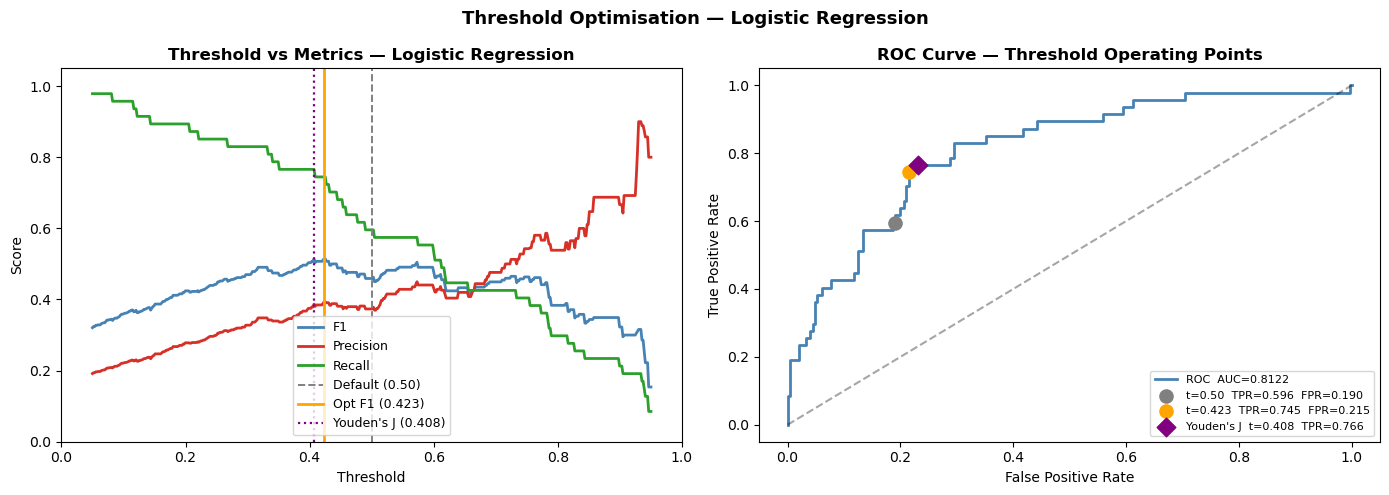

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score

best_proba  = results[best_name]['y_prob']
DEFAULT_T   = 0.50
thresholds  = np.linspace(0.05, 0.95, 500)

f1s   = np.array([f1_score(y_test,   (best_proba >= t).astype(int), zero_division=0) for t in thresholds])
precs = np.array([precision_score(y_test, (best_proba >= t).astype(int), zero_division=0) for t in thresholds])
recs  = np.array([recall_score(y_test,    (best_proba >= t).astype(int), zero_division=0) for t in thresholds])

fpr_c, tpr_c, roc_t = roc_curve(y_test, best_proba)
best_youden_idx      = int(np.argmax(tpr_c - fpr_c))
best_t_youden        = float(roc_t[best_youden_idx])
best_t_f1            = float(thresholds[np.argmax(f1s)])
opt_t                = best_t_f1

y_pred_default = (best_proba >= DEFAULT_T).astype(int)
y_pred_opt     = (best_proba >= opt_t).astype(int)

metrics_before = {
    'ROC-AUC'  : results[best_name]['roc_auc'],
    'F1'       : f1_score(y_test, y_pred_default),
    'Precision': precision_score(y_test, y_pred_default, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_default, zero_division=0),
}
metrics_after = {
    'ROC-AUC'  : results[best_name]['roc_auc'],
    'F1'       : f1_score(y_test, y_pred_opt),
    'Precision': precision_score(y_test, y_pred_opt, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_opt, zero_division=0),
}

best_threshold = DEFAULT_T
if metrics_after['F1'] > metrics_before['F1']:
    best_threshold = opt_t
    rep_opt = classification_report(y_test, y_pred_opt, output_dict=True)
    results[best_name].update({
        'y_pred'   : y_pred_opt,
        'f1'       : metrics_after['F1'],
        'precision': rep_opt['1']['precision'],
        'recall'   : rep_opt['1']['recall'],
    })
    summary = pd.DataFrame({
        n: {k: v for k, v in d.items() if k not in ('model', 'y_pred', 'y_prob', 'Xte')}
        for n, d in results.items()
    }).T.round(4).sort_values('roc_auc', ascending=False)
    best_name = summary.index[0]

print(f"Threshold selected : {best_threshold:.3f}  (max-F1)  |  Youden's J : {best_t_youden:.3f}")
print(f"\n{'Metric':<12} {'Default (0.50)':>15} {'Opt ({:.3f})'.format(opt_t):>18}  {'Delta':>8}")
print("-" * 56)
for m in ['ROC-AUC', 'F1', 'Precision', 'Recall']:
    b, a = metrics_before[m], metrics_after[m]
    print(f"{m:<12} {b:>15.4f} {a:>18.4f}  {a-b:>+8.4f}")

print(f"\nUpdated model summary (threshold={best_threshold:.3f} applied to {best_name}):")
print(summary[['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(thresholds, f1s,   color='steelblue', lw=2,   label='F1')
ax.plot(thresholds, precs, color='#d73027',   lw=2,   label='Precision')
ax.plot(thresholds, recs,  color='#2ca02c',   lw=2,   label='Recall')
ax.axvline(DEFAULT_T,    color='gray',   linestyle='--', lw=1.4, label=f'Default ({DEFAULT_T:.2f})')
ax.axvline(opt_t,        color='orange', linestyle='-',  lw=2.0, label=f'Opt F1 ({opt_t:.3f})')
ax.axvline(best_t_youden,color='purple', linestyle=':',  lw=1.6, label=f"Youden's J ({best_t_youden:.3f})")
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title(f'Threshold vs Metrics — {best_name}', fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

ax = axes[1]
ax.plot(fpr_c, tpr_c, color='steelblue', lw=2,
        label=f'ROC  AUC={results[best_name]["roc_auc"]:.4f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.35)
idx_default = int(np.argmin(np.abs(roc_t - DEFAULT_T)))
idx_opt     = int(np.argmin(np.abs(roc_t - opt_t)))
ax.scatter(fpr_c[idx_default], tpr_c[idx_default], color='gray',   s=90, zorder=5,
           label=f't=0.50  TPR={tpr_c[idx_default]:.3f}  FPR={fpr_c[idx_default]:.3f}')
ax.scatter(fpr_c[idx_opt],     tpr_c[idx_opt],     color='orange', s=90, zorder=5,
           label=f't={opt_t:.3f}  TPR={tpr_c[idx_opt]:.3f}  FPR={fpr_c[idx_opt]:.3f}')
ax.scatter(fpr_c[best_youden_idx], tpr_c[best_youden_idx], color='purple', s=90,
           marker='D', zorder=5,
           label=f"Youden's J  t={best_t_youden:.3f}  TPR={tpr_c[best_youden_idx]:.3f}")
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Threshold Operating Points', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
plt.suptitle(f'Threshold Optimisation — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

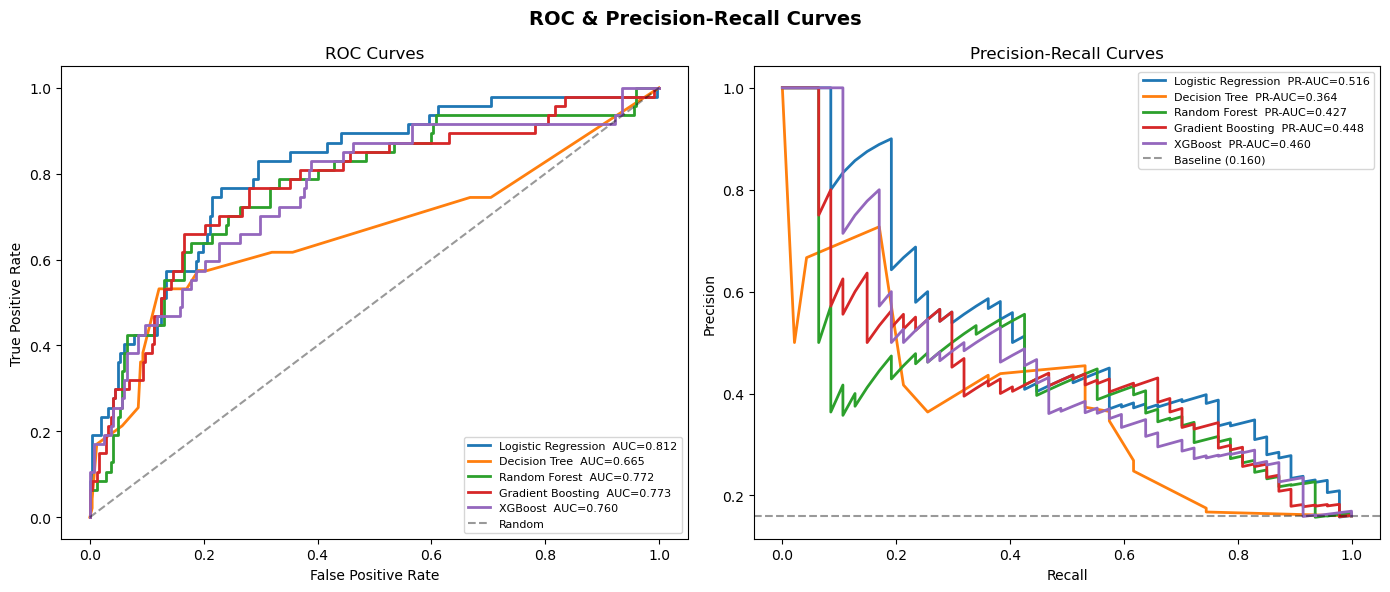

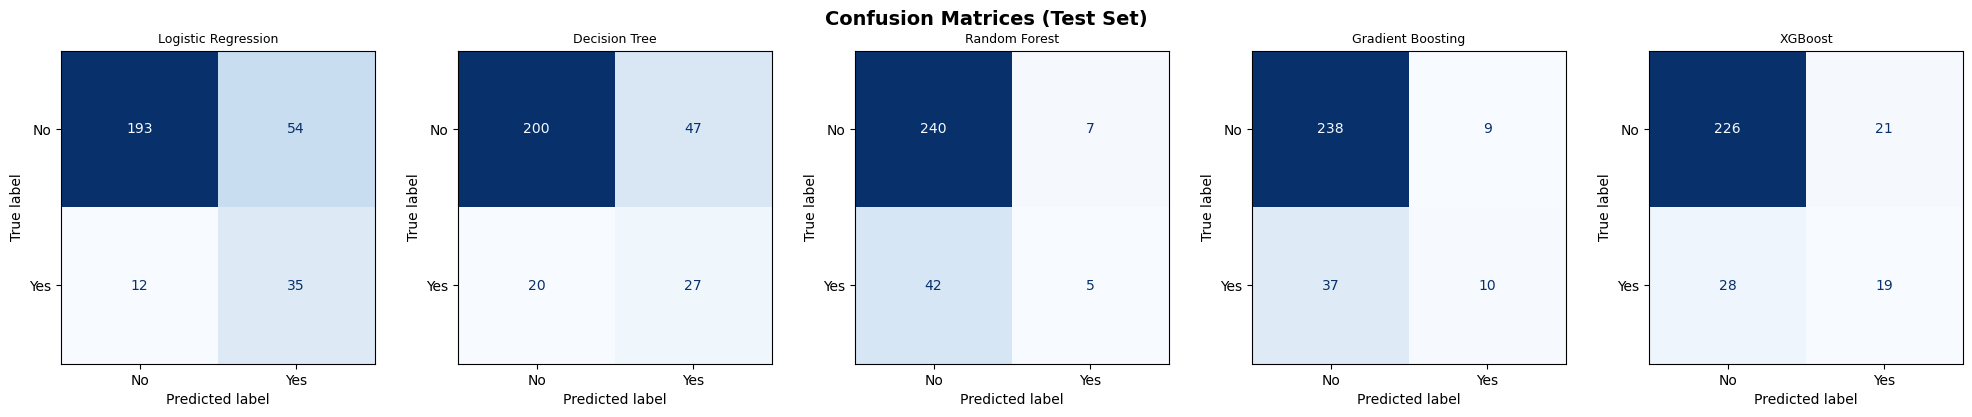

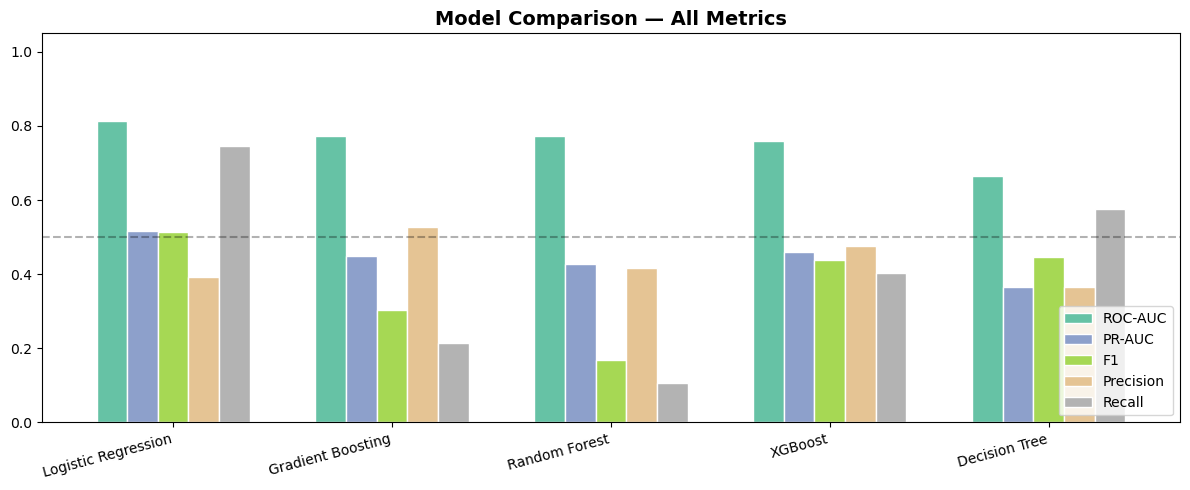

In [5]:
import seaborn as sns
palette = sns.color_palette('tab10', len(results))

# 1. ROC + PR curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for color, (name, d) in zip(palette, results.items()):
    fpr, tpr, _ = roc_curve(y_test, d['y_prob'])
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name}  AUC={d['roc_auc']:.3f}")
    prec, rec, _ = precision_recall_curve(y_test, d['y_prob'])
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{name}  PR-AUC={d['pr_auc']:.3f}")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set(title='ROC Curves', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[0].legend(fontsize=8, loc='lower right')

baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='k', alpha=0.4, label=f'Baseline ({baseline:.3f})')
axes[1].set(title='Precision-Recall Curves', xlabel='Recall', ylabel='Precision')
axes[1].legend(fontsize=8, loc='upper right')

plt.suptitle('ROC & Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Confusion matrices
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
for ax, (name, d) in zip(axes, results.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, d['y_pred']),
                           display_labels=['No', 'Yes']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)
plt.suptitle('Confusion Matrices (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Metrics bar chart
metrics_df = summary[['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']].copy()
metrics_df.columns = ['ROC-AUC', 'PR-AUC', 'F1', 'Precision', 'Recall']
ax = metrics_df.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white', width=0.7)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticklabels(metrics_df.index, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.axhline(0.5, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

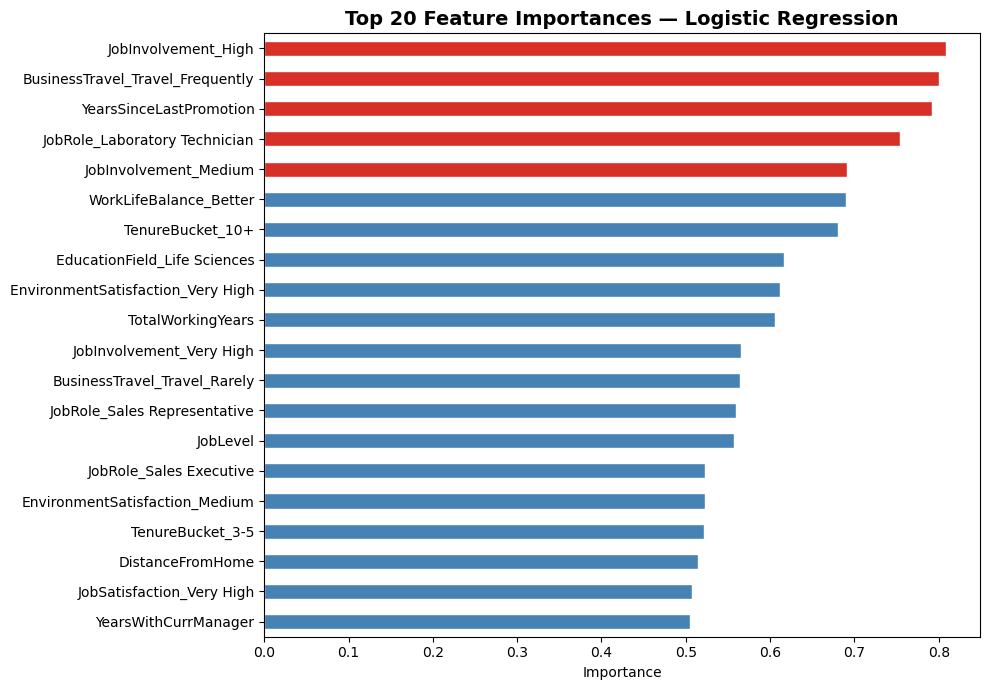


Top 10 attrition drivers (Logistic Regression):
  JobInvolvement_High                               0.8085
  BusinessTravel_Travel_Frequently                  0.7999
  YearsSinceLastPromotion                           0.7922
  JobRole_Laboratory Technician                     0.7536
  JobInvolvement_Medium                             0.6912
  WorkLifeBalance_Better                            0.6896
  TenureBucket_10+                                  0.6805
  EducationField_Life Sciences                      0.6159
  EnvironmentSatisfaction_Very High                 0.6119
  TotalWorkingYears                                 0.6063


In [6]:
best  = results[best_name]
model = best['model']

if hasattr(model, 'feature_importances_'):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
elif hasattr(model, 'coef_'):
    importances = pd.Series(np.abs(model.coef_[0]), index=X_train_sc.columns)
else:
    importances = None

if importances is not None:
    top20  = importances.nlargest(20).sort_values()
    cutoff = top20.quantile(0.75)
    colors = ['#d73027' if v >= cutoff else 'steelblue' for v in top20.values]

    fig, ax = plt.subplots(figsize=(10, 7))
    top20.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Top 20 Feature Importances — {best_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print(f"\nTop 10 attrition drivers ({best_name}):")
    for feat, imp in importances.nlargest(10).items():
        print(f"  {feat:<48s}  {imp:.4f}")

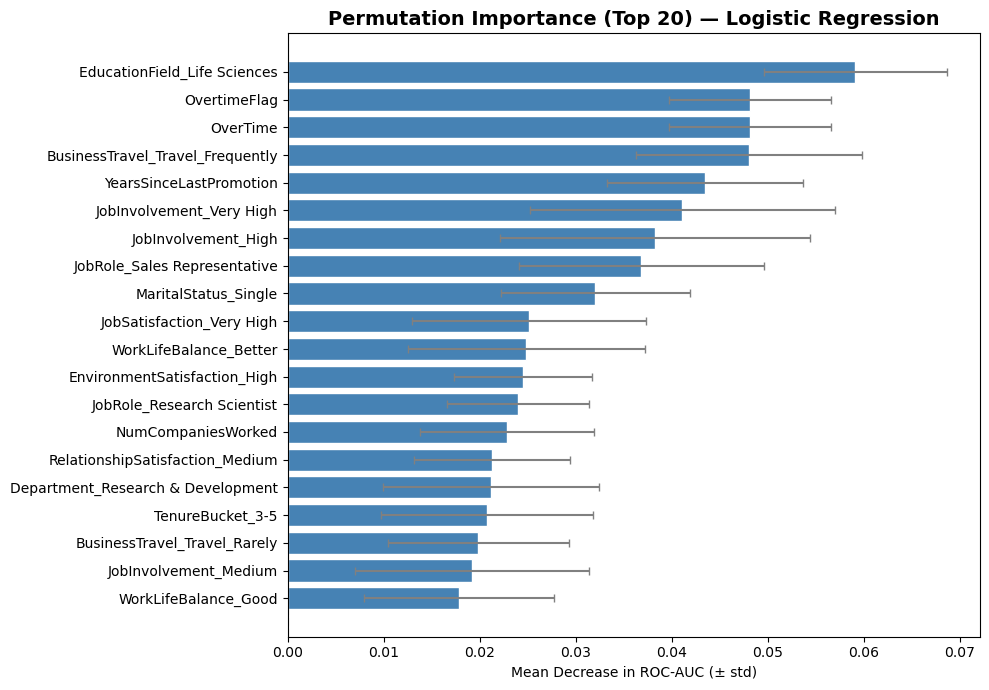


Top 10 by permutation importance:
  EducationField_Life Sciences                      0.0591
  OverTime                                          0.0482
  OvertimeFlag                                      0.0482
  BusinessTravel_Travel_Frequently                  0.0481
  YearsSinceLastPromotion                           0.0434
  JobInvolvement_Very High                          0.0411
  JobInvolvement_High                               0.0383
  JobRole_Sales Representative                      0.0368
  MaritalStatus_Single                              0.0321
  JobSatisfaction_Very High                         0.0252


In [7]:
from sklearn.inspection import permutation_importance

best_model = results[best_name]['model']

# Use the correct test set for whichever model won
if best_name == 'Logistic Regression':
    Xte_eval = X_test_sc
elif best_name == 'XGBoost':
    Xte_eval = Xte_np
else:
    Xte_eval = X_test

perm = permutation_importance(
    best_model, Xte_eval, y_test,
    n_repeats=30, scoring='roc_auc', random_state=42, n_jobs=-1
)

# Use numpy positional indexing to avoid duplicate-label issues with pandas
top20_pos  = np.argsort(perm.importances_mean)[-20:]
sort_order = np.argsort(perm.importances_mean[top20_pos])
sorted_pos = top20_pos[sort_order]

top20_names = np.array(X_train.columns)[sorted_pos]
top20_mean  = perm.importances_mean[sorted_pos]
top20_std   = perm.importances_std[sorted_pos]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_names, top20_mean, xerr=top20_std,
        color='steelblue', edgecolor='white', ecolor='gray', capsize=3)
ax.axvline(0, color='k', linestyle='--', alpha=0.4)
ax.set_title(f'Permutation Importance (Top 20) — {best_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Decrease in ROC-AUC (± std)')
plt.tight_layout()
plt.show()

perm_series = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)
print("\nTop 10 by permutation importance:")
for feat, imp in perm_series.head(10).items():
    print(f"  {feat:<48s}  {imp:.4f}")

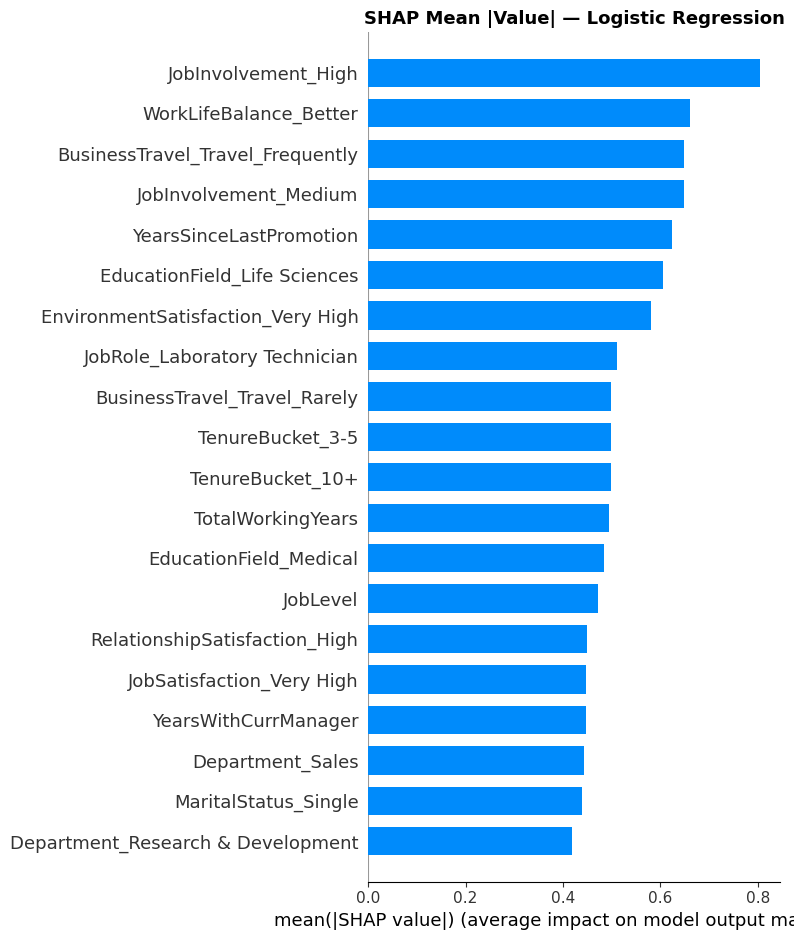

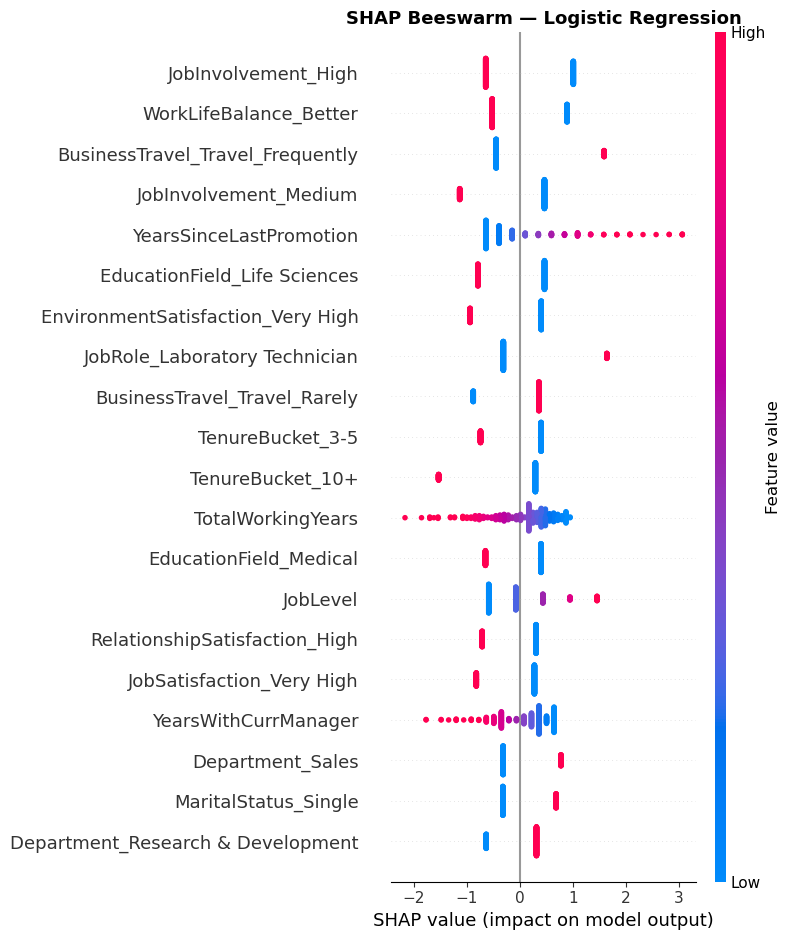

Top 3 features by mean |SHAP|: ['JobInvolvement_High', 'WorkLifeBalance_Better', 'BusinessTravel_Travel_Frequently']


<Figure size 800x500 with 0 Axes>

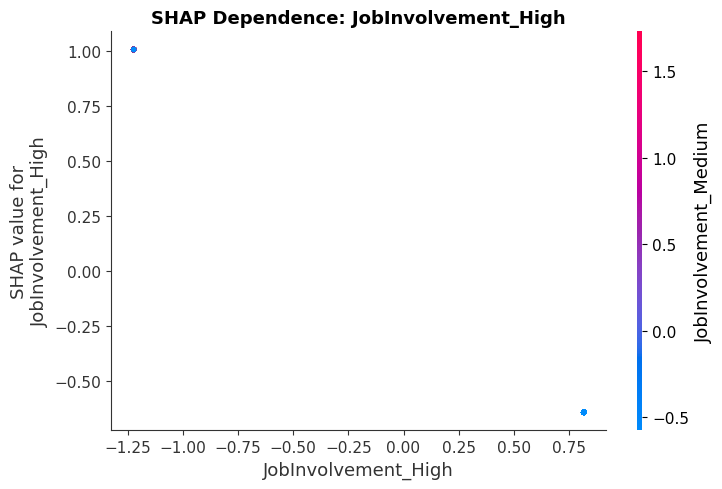

<Figure size 800x500 with 0 Axes>

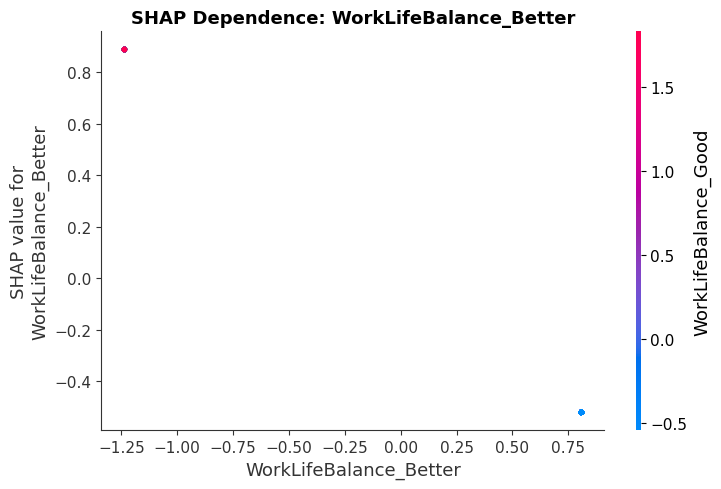

<Figure size 800x500 with 0 Axes>

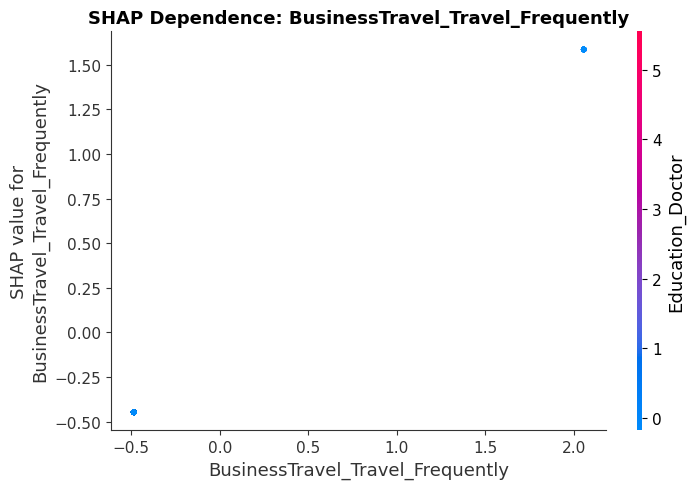

In [8]:
!pip install shap -q
import shap
shap.initjs()

best_model = results[best_name]['model']

# Build explainer and get SHAP values for the test set
if best_name == 'XGBoost':
    explainer  = shap.TreeExplainer(best_model)
    shap_input = Xte_np
elif hasattr(best_model, 'feature_importances_'):
    explainer  = shap.TreeExplainer(best_model)
    shap_input = X_test.values
else:
    explainer  = shap.LinearExplainer(best_model, X_train_sc.values)
    shap_input = X_test_sc.values

shap_vals = explainer.shap_values(shap_input)

# For tree models that return [class0, class1] lists
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]

# Display DataFrame with real column names for all plots
feat_names = X_train.columns.tolist()
X_display  = pd.DataFrame(shap_input, columns=feat_names)

# --- SHAP Bar Summary (mean |SHAP|) ---
plt.figure()
shap.summary_plot(shap_vals, X_display, plot_type='bar', show=False, max_display=20)
plt.title(f'SHAP Mean |Value| — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- SHAP Beeswarm Summary ---
plt.figure()
shap.summary_plot(shap_vals, X_display, show=False, max_display=20)
plt.title(f'SHAP Beeswarm — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Dependence Plots for Top 3 Features ---
mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=feat_names)
top3_feats    = mean_abs_shap.nlargest(3).index.tolist()
print(f"Top 3 features by mean |SHAP|: {top3_feats}")

for feat in top3_feats:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(feat, shap_vals, X_display, show=False)
    plt.title(f'SHAP Dependence: {feat}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

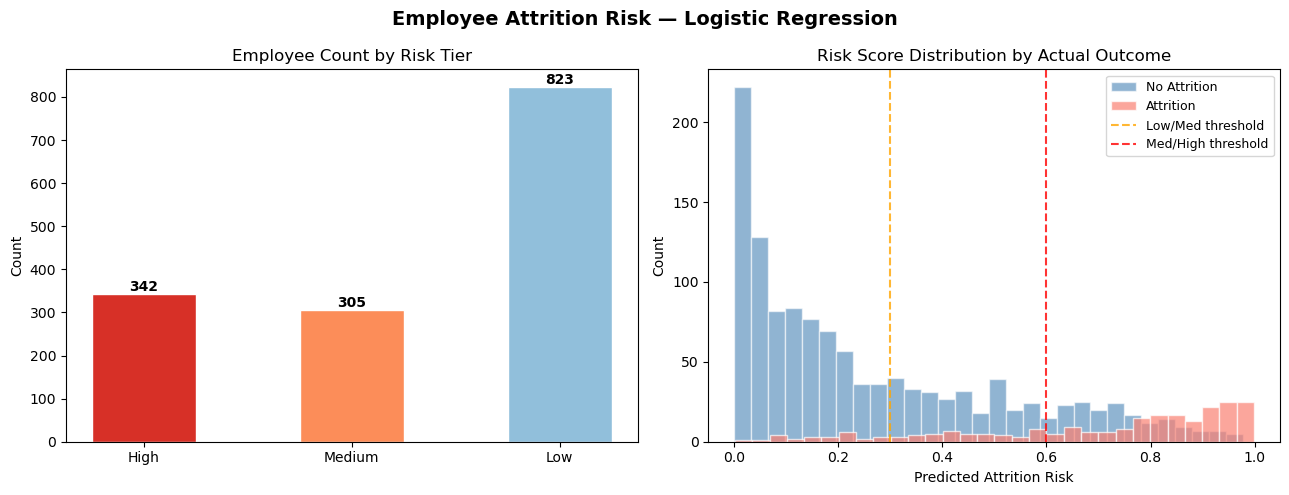


Risk tier summary:
          Employees Actual Attrition Rate
RiskTier                                 
Low             823                  3.0%
Medium          305                 14.4%
High            342                 49.1%

Top 20 highest-risk employees:
    EmployeeNumber  AttritionRisk RiskTier  ActualAttrition
1              622       0.998711     High                1
2              235       0.996431     High                1
3             1273       0.996382     High                1
4             1487       0.996196     High                1
5              911       0.994538     High                1
6             1716       0.989435     High                1
7               55       0.989289     High                1
8             1494       0.987999     High                1
9              147       0.987388     High                1
10             167       0.987076     High                1
11             959       0.987030     High                1
12             478

In [9]:
X_all = df.drop(columns=['Attrition', 'EmployeeNumber'], errors='ignore')

if best_name == 'Logistic Regression':
    X_all_input = scaler.transform(X_all)
elif best_name == 'XGBoost':
    X_all_input = X_all.to_numpy()
else:
    X_all_input = X_all.values

risk_scores = best_model.predict_proba(X_all_input)[:, 1]

risk_df = pd.DataFrame({
    'EmployeeNumber': df['EmployeeNumber'].values,
    'ActualAttrition': df['Attrition'].values,
    'AttritionRisk':   risk_scores,
}).sort_values('AttritionRisk', ascending=False).reset_index(drop=True)
risk_df.index += 1  # 1-based rank

risk_df['RiskTier'] = pd.cut(
    risk_df['AttritionRisk'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

# Risk tier bar chart
tier_counts = risk_df['RiskTier'].value_counts().reindex(['High', 'Medium', 'Low'])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(tier_counts.index, tier_counts.values,
            color=['#d73027', '#fc8d59', '#91bfdb'], edgecolor='white', width=0.5)
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 8, str(v), ha='center', fontweight='bold')
axes[0].set_title('Employee Count by Risk Tier')
axes[0].set_ylabel('Count')

axes[1].hist(risk_df[risk_df['ActualAttrition'] == 0]['AttritionRisk'],
             bins=30, alpha=0.6, label='No Attrition', color='steelblue', edgecolor='white')
axes[1].hist(risk_df[risk_df['ActualAttrition'] == 1]['AttritionRisk'],
             bins=30, alpha=0.7, label='Attrition',    color='salmon',    edgecolor='white')
axes[1].axvline(0.3, color='orange', linestyle='--', alpha=0.8, label='Low/Med threshold')
axes[1].axvline(0.6, color='red',    linestyle='--', alpha=0.8, label='Med/High threshold')
axes[1].set_title('Risk Score Distribution by Actual Outcome')
axes[1].set_xlabel('Predicted Attrition Risk')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

plt.suptitle(f'Employee Attrition Risk — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRisk tier summary:")
print(risk_df.groupby('RiskTier', observed=True)['ActualAttrition'].agg(['count','mean'])
      .rename(columns={'count':'Employees','mean':'Actual Attrition Rate'})
      .assign(**{'Actual Attrition Rate': lambda x: x['Actual Attrition Rate'].map('{:.1%}'.format)}))

print(f"\nTop 20 highest-risk employees:")
print(risk_df[['EmployeeNumber','AttritionRisk','RiskTier','ActualAttrition']]
      .head(20).to_string())

In [10]:
import pickle

_model_artifacts = {
    'df'        : df,
    'results'   : results,
    'best_name' : best_name,
    'best_model': best_model,
    'scaler'    : scaler,
    'X_train'   : X_train,
    'X_train_sc': X_train_sc,
    'X_test'    : X_test,
    'X_test_sc' : X_test_sc,
    'y_train'   : y_train,
    'y_test'    : y_test,
    'Xtr_np'    : Xtr_np,
    'Xte_np'    : Xte_np,
    'risk_df'   : risk_df,
}
with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(_model_artifacts, f)
print("Saved model_artifacts.pkl")

Saved model_artifacts.pkl
